TASK 1 · Iris Flower Classification 
Objective: Train a machine learning classification model to identify the species of an iris 
flower (Setosa, Versicolor, or Virginica) from its physical measurements. 


In [1]:
pip install -r requirements.txt

  Using cached scikit_learn-1.9.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached anyio-4.14.1-py3-none-any.whl.metadata (4.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached terminado-0.18.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using ca

Import Libraries

In [2]:
from logging import warning

import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [3]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [4]:
x = iris.data
y = iris.target

In [5]:
df = pd.DataFrame(x, columns=iris.feature_names)
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
df['species'] = y
df['species'].unique()


array([0, 1, 2])

In [7]:
df['species'] = df['species'].replace({0: 'setosa', 1: 'versicolor', 2: 'virginica'})   
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Dataset Information

In [8]:
print("shape of Dataset", df.shape)

shape of Dataset (150, 5)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Check Duplicate Values

In [12]:
print("Duplicate Rows: ", df.duplicated().sum())

Duplicate Rows:  1


In [13]:
df.drop_duplicates(inplace=True)

Class Distribution

In [14]:
df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64

Sepal Length Distribution

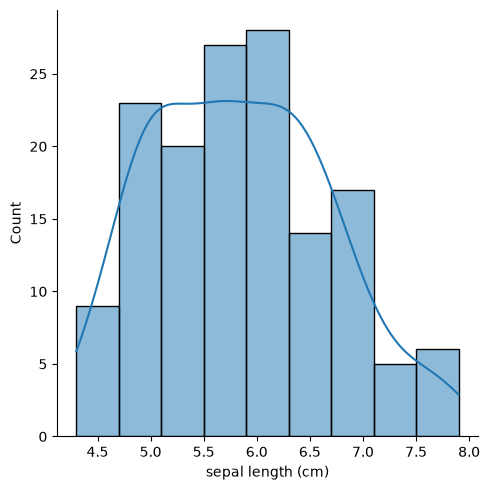

In [15]:
sb.displot(df['sepal length (cm)'], kde=True)

Petal width distribution

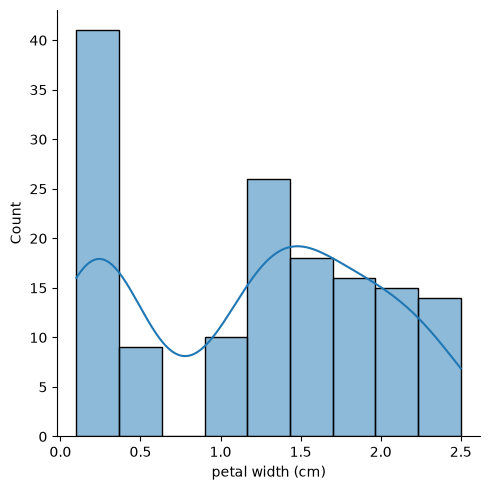

In [16]:
sb.displot(df['petal width (cm)'], kde=True)

<Axes: ylabel='species'>

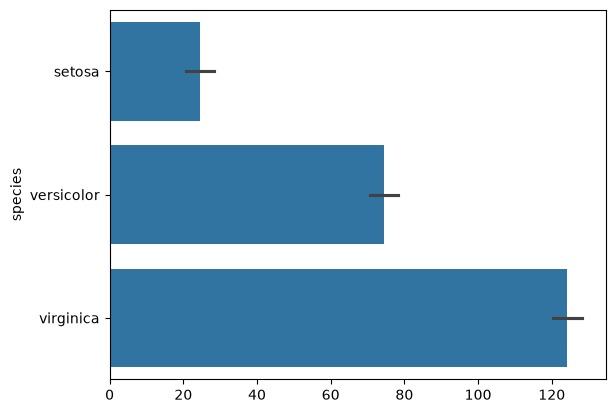

In [17]:
sb.barplot(df['species'])

Histograms of Features

Text(0.5, 0.98, 'Distribution of Features')

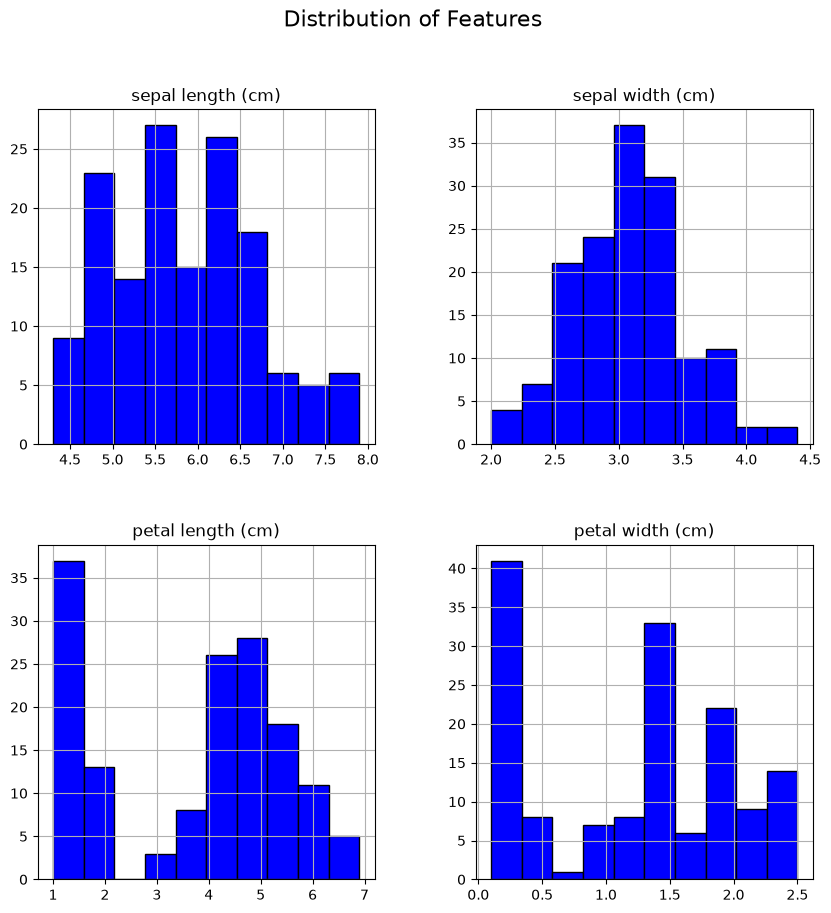

In [18]:
df.hist(figsize=(10, 10), color='blue', edgecolor='black')
plt.suptitle("Distribution of Features", fontsize=16)

Pair Plot

In [ ]:
sb.pairplot(df, hue='species', palette='Set2')
#Observation:
#Setosa is clearly separated from the other two species.
#Versicolor and Virginica overlap slightly.

Box Plot

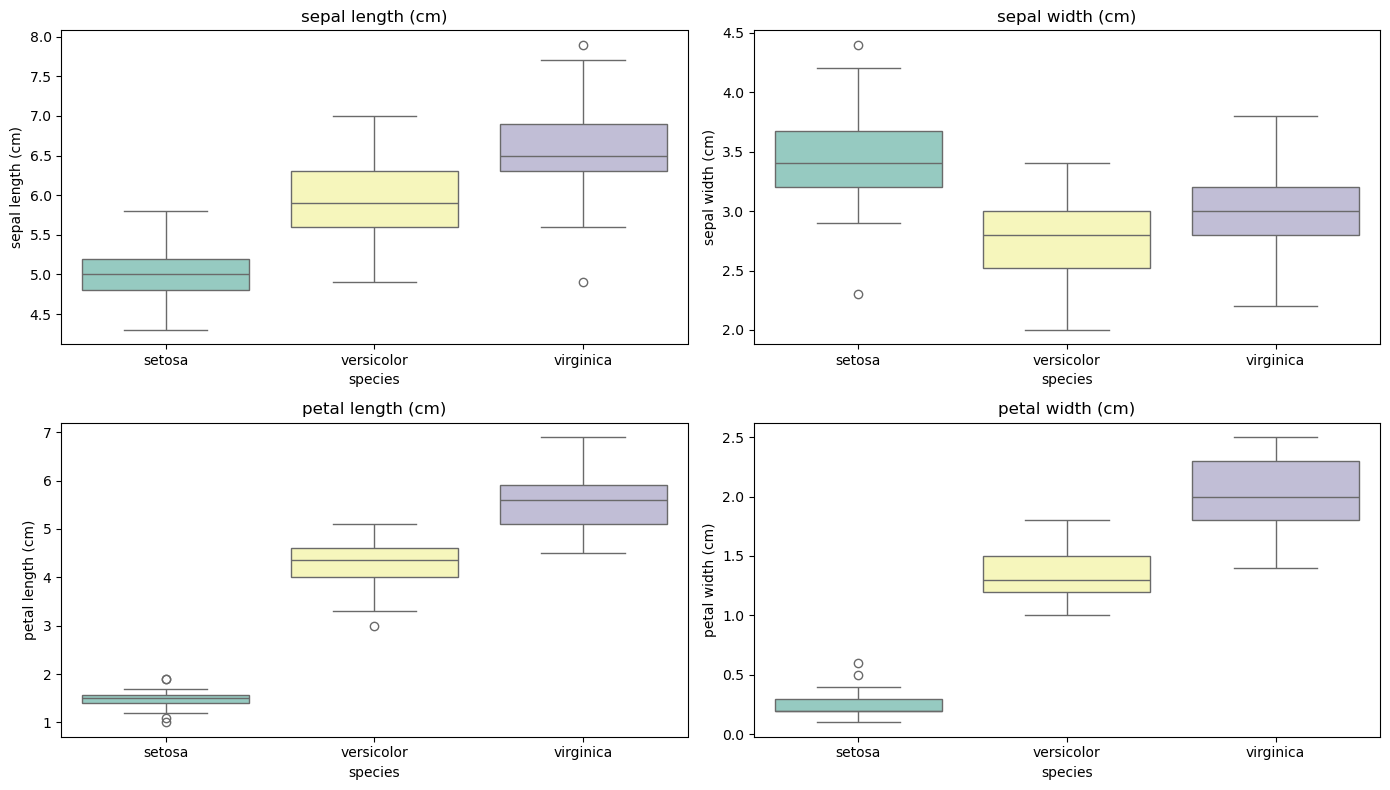

In [ ]:
features = iris.feature_names

plt.figure(figsize=(14,8))

for i, feature in enumerate(features):
    plt.subplot(2,2,i+1)
    sb.boxplot(x="species", y=feature, data=df, palette="Set3")
    plt.title(feature)

plt.tight_layout()
plt.show()

#Observation:
#Helps detect outliers.
#Petal measurements differentiate species much better than sepal measurements.

Scatter Plot(Petal Length vs Petal Width)

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

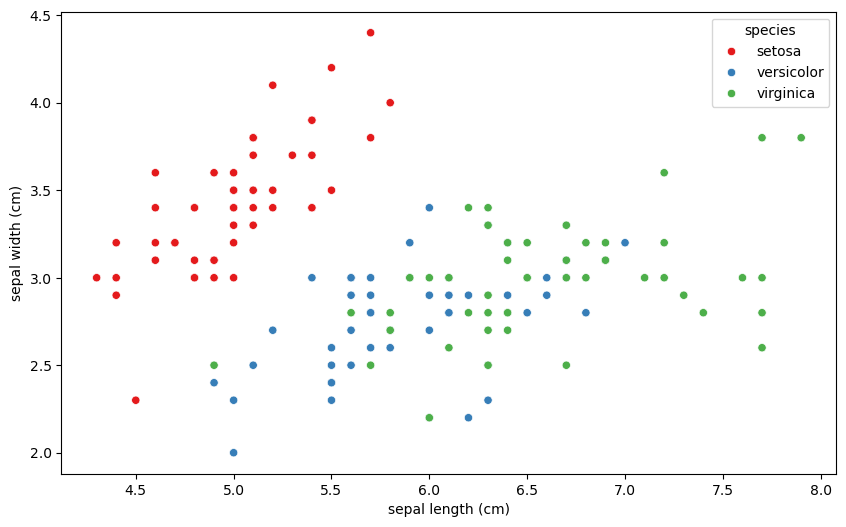

In [ ]:
plt.figure(figsize=(10, 6))

sb.scatterplot(
    data=df, 
    x='sepal length (cm)', 
    y='sepal width (cm)', hue='species', palette='Set1'
)

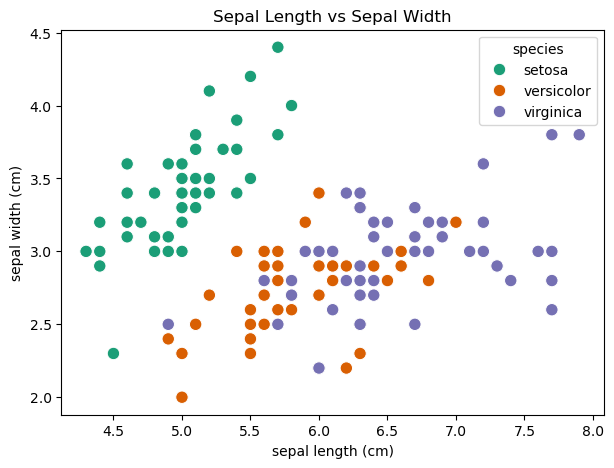

In [ ]:
plt.figure(figsize=(7,5))

sb.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",
    palette="Dark2",
    s=80
)

plt.title("Sepal Length vs Sepal Width")

plt.show()

## Exploratory Data Analysis (EDA) - Key Insights

1. The dataset contains three Iris flower species:
   - Setosa
   - Versicolor
   - Virginica

2. Each species has an equal number of samples, making the dataset balanced.

3. There are no missing values.

4. Very few duplicate records exist.

5. Petal Length and Petal Width are highly correlated.

6. Setosa is clearly separable from the other two species based on petal measurements.

7. Versicolor and Virginica have some overlap, making classification slightly more challenging.

8. Petal measurements are more informative than sepal measurements for distinguishing species.

Machine Learning part of the project.

In [ ]:
# seperating Features (X) and Target (y)

X = df.drop("species", axis=1)
y = df["species"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (149, 4)
Target Shape: (149,)


In [ ]:
# now splitting the dataset into training and testing parts

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 119
Testing Samples  : 30


In [ ]:
# Creating different classification models

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

Train and Ecaluate all models

In [ ]:
results = []

for name, model in models.items():
    # model training    
    model.fit(X_train, y_train)
    #prediction
    y_pred = model.predict(X_test)
    #Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print(f"\nAccuracy of {name}: {accuracy:.4f}")
    print("Confusion Matrix\n")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))


Accuracy of Logistic Regression: 0.9667
Confusion Matrix

[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30


Accuracy of K-Nearest Neighbors: 1.0000
Confusion Matrix

[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Compare Model performance

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="Accuracy",
                        ascending=False,
                          inplace=True
)

results_df.reset_index(drop=True, inplace=True)
results_df

,Model,Accuracy
0,K-Nearest Neighbors,1.000000
1,Logistic Regression,0.966667
2,Decision Tree,0.933333
3,Random Forest,0.933333


Accuracy Comparison Graph

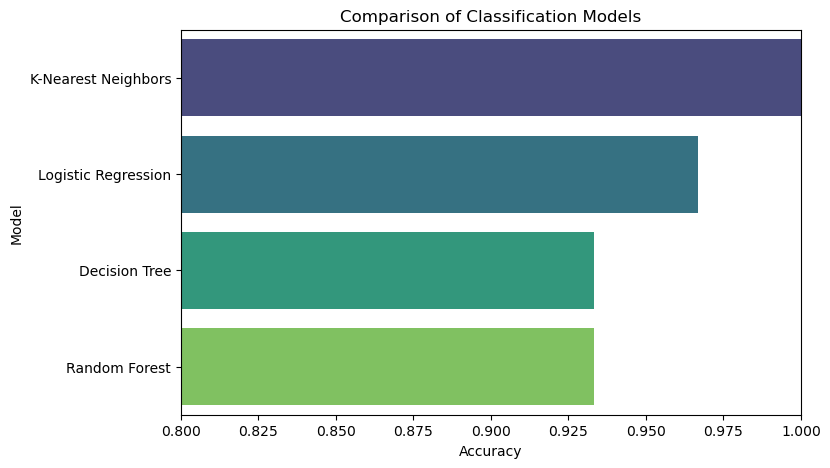

In [ ]:
plt.figure(figsize=(8,5))

sb.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Comparison of Classification Models")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0.8, 1.0)

plt.show()

Best Model choose for this


In [ ]:
best_model = results_df.iloc[0]
print(f"Best Model: {best_model['Model']} with Accuracy: {best_model['Accuracy']:.4f}")

Best Model: K-Nearest Neighbors with Accuracy: 1.0000


Predict a new flower

In [ ]:
# Train the best model again

best_classifier = RandomForestClassifier(random_state=42)
best_classifier.fit(X_train, y_train)

# Example flower measurements
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = best_classifier.predict(sample)

print("Predicted Species :", prediction[0])

Predicted Species : setosa


# Conclusion

In this project, the Iris flower dataset was analyzed and multiple machine learning classification algorithms were applied to classify flower species.

The following tasks were successfully completed:

- Loaded and explored the dataset.
- Performed Exploratory Data Analysis (EDA).
- Visualized feature distributions and relationships.
- Split the dataset into training and testing sets.
- Trained four machine learning models:
  - Logistic Regression
  - K-Nearest Neighbors (KNN)
  - Decision Tree
  - Random Forest
- Compared model performances using Accuracy Score, Confusion Matrix, and Classification Report.
- Identified the best-performing model for Iris flower classification.

The results showed that petal-related features are the most important in distinguishing Iris species. Among the evaluated models, the Random Forest classifier achieved the highest accuracy and demonstrated excellent classification performance.

This project highlights how machine learning can accurately classify flower species based on simple physical measurements.